# Solução aproximada de PVIs para EDOs

Consideramos um Problema de Valor Inicial (PVI) da forma

\begin{equation}\left\{\begin{aligned}
& y^\prime  = f(t, y), \qquad t_0 \leq t \leq t_f \\
& y(t_0) = y_{0}
\end{aligned}\right.
\end{equation}

onde a função $x(t)$ definida no intervalo $[t_0, t_f]$ é a nossa incógnita,  $y^\prime$ representa sua primeira derivada com relação à $t$, $f(t,y)$ é uma função conhecida e $y_0$ é a  condição inicial do problema.

Observamos que a Equação Diferencial Ordinária (EDO) $y^\prime  = f(t, y)$ possui, em geral, infinitas soluções, mas a solução do PVI que além da EDO deve satisfazer também a condição inicial é definida, de modo geral, de forma única. Assim, a condição inicial nos permite escolher uma solução individual da EDO.

## Exemplo: O pêndulo simples



**Representação esquemática (fonte: wikimedia.org)**

![pendulum](https://upload.wikimedia.org/wikipedia/commons/a/a3/HarmOs9.png)


---



Nesse modelo considera-se que apenas a força de gravidade atúa sobre o corpo e que o movimento do mesmo acontece num plano vertical. Nesse caso as equações da mecânica clássica tomam a seguinte forma:

$$
\left\{\begin{aligned}
& \frac{d^2\theta}{dt^2} + \frac{g}{l}\,\sin(\theta) = 0\\
& \theta(0) = \theta_0,\quad \frac{d\theta}{dt}(0) = \omega_0
\end{aligned}
\right.
$$

onde $\theta$ é o ângulo com a vertical, $g$ é a aceleração da gravidade, $l$ é o comprimento da haste, e $\theta_0$ e $\omega_0$ representam o ângulo e a velocidade angular iniciais, respectivamente.

Essa EDO de 2$^{da}$ ordem pode ser rescrita como um sistema de duas EDOs de 1$^{ra}$ ordem. Assim temos o seguinte PVI

$$
\left\{\begin{aligned}
& y_1^\prime  = y_2\\
& y_2^\prime = -\frac{g}{l}\,\sin(y_1) \\
& y_1(0) = y_{10},\quad y_2(0) = y_{20}
\end{aligned}
\right.
$$

onde $y_1 = \theta$, $y_2 = \frac{d \theta}{dt}$, $y_{10} = \theta_0$ e $y_{20} = \omega_0$.

---

O seguinte código determina a solução aproximada desse PVI quando $\theta_0 = \pi/3$, $\omega_0=0$, $g=9.81$ e $l=1$ no intervalo de tempo $[0, 10]$.
Vamos a usar a função ***solve_ivp*** para a resolução aproximada de problemas de valor inicial (PVI) para EDOs  do [Scipy](https://docs.scipy.org/doc/scipy-1.17.0/reference/generated/scipy.integrate.solve_ivp.html) e a capacidade do [NumPy](https://http://www.numpy.org/)  para trabalhar com dados vetoriais (***ndarrays***).


In [ ]:
#@title
import numpy as nup
from scipy.integrate import solve_ivp
from math import pi, sin, cos

#constantes

#gravidade
g = 9.81

#comprimento do pêndulo
l = 1.0

def f(t, y):
    # a função retorna um vetor (objeto numpy.ndarray), construido a partir das duas
    # componentes y[0] e y[1] do vetor y usando a função numpy.array.
    return nup.array( [ y[1], -(g/l)*sin(y[0]) ] )

np = 2000
t0 = 0.0
tf = 10.0
y0 = [pi/3, 0]
#y0 = [pi/3, -5.0]
#y0 = [pi/3, -5.5]

sol = solve_ivp(f, [t0, tf], y0, t_eval=nup.linspace(t0, tf, np+1), rtol=1e-5, atol=1e-6)

Agora vamos mostrar a solução obtida.

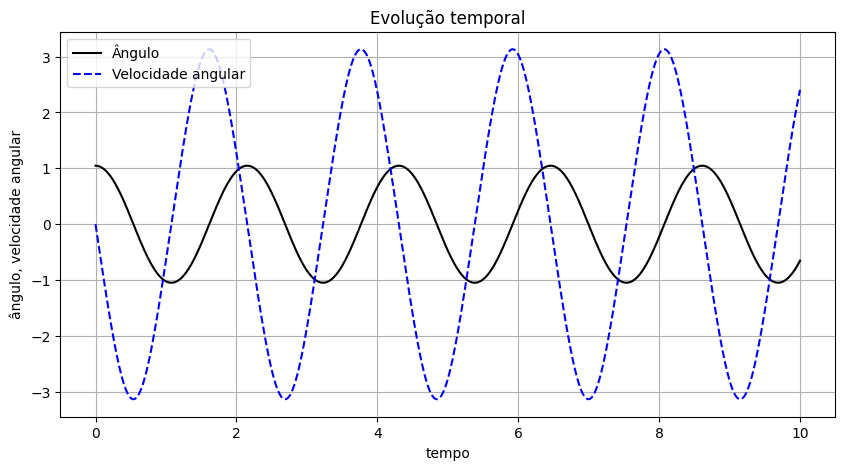

In [ ]:
#@title
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,5))

plt.plot( sol.t, sol.y[0], 'k-')
plt.plot( sol.t, sol.y[1], 'b--')

plt.xlabel(u'tempo')
plt.ylabel('ângulo, velocidade angular')
plt.title(u'Evolução temporal')
plt.legend( ['Ângulo', 'Velocidade angular'] )

plt.grid(True)

A trajetória no espaço de fase por ser periódica corresponde a uma curva fechada.

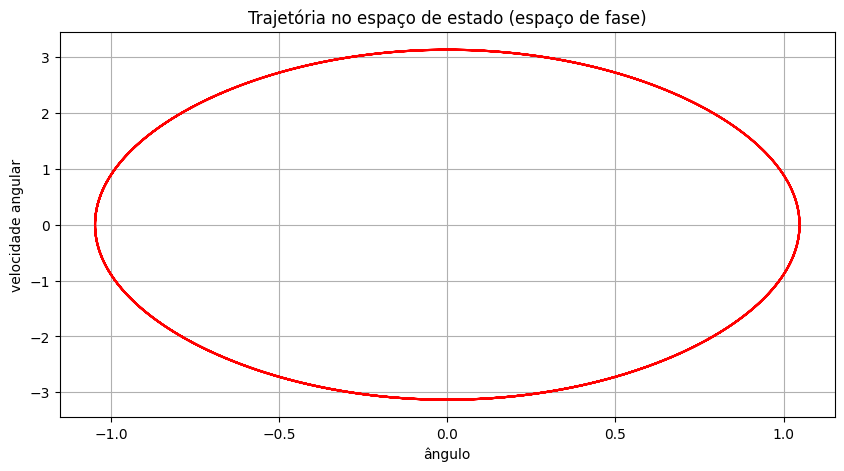

In [ ]:
fig = plt.figure(figsize=(10,5))

plt.plot( sol.y[0],sol.y[1], 'r-')

plt.xlabel(u'ângulo')
plt.ylabel('velocidade angular')
plt.title(u'Trajetória no espaço de estado (espaço de fase)')

plt.grid(True)

In [ ]:
#@title
# Código para criar a animação dos resultados

from matplotlib import animation, rc
from IPython.display import HTML


# First set up the figure, the axes, and the plot element
fig, ax = plt.subplots()
plt.close()

ax.set_xlim(-1.1*l, 1.1*l)
ax.set_ylim(-1.1*l, 1.35*l)
ax.set_aspect('equal')

ln1, = ax.plot([], [], '--bo')
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)
time_template = 'time = %.2f s'

# initialization function: plot the background of each frame
def init():
    ln1.set_data([], [])
    time_text.set_text('')

    return ln1, time_text

# animation function: this is called sequentially
def animate(i):
    xdata = [0, l*sin(sol.y[0,i])]
    ydata = [0, -l*cos(sol.y[0,i])]
    ln1.set_data(xdata, ydata)

    time_text.set_text(time_template % (t0+i*(tf-t0)/np))

    return ln1, time_text

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=range(0,np+1,20), interval=200, repeat_delay=500, blit=True)
rc('animation', html='jshtml')
anim